# 03 — The split, the model, and what it had to beat

Conversion does not hold still across the five months, which makes the **split** the most
consequential decision here — bigger than the choice of algorithm. So the split comes
first and the model follows in the same notebook: they are one argument.

The framing that decides the metrics: this is **ranking under a capacity constraint**, not
classification. At a 9% base rate "nobody buys" is 91% accurate and useless. What the
floor needs is *how many buyers are in the first 500 calls*.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, ".")
from pe_style import *
from priority_engine import features, metrics
from priority_engine.config import CFG
from sklearn.calibration import CalibratedClassifierCV
import joblib

df = leads_db()
Y = "completed_purchase"
BASE = df[Y].mean()
HOLDOUT_DAYS = CFG["train"]["holdout_days"]
VALID_DAYS = CFG["train"]["validation_days"]

print(f"period      {df['created_at'].min():%Y-%m-%d}  →  {df['created_at'].max():%Y-%m-%d}")
print(f"leads       {len(df):,}")
print(f"holdout     newest {HOLDOUT_DAYS} days (train.holdout_days)")
print(f"validation  the {VALID_DAYS} days before it (train.validation_days)")

period      2026-04-01  →  2026-08-28
leads       50,000
holdout     newest 28 days (train.holdout_days)
validation  the 28 days before it (train.validation_days)


## 1. The market moved while we were measuring it

before the cutoff   9.58%
holdout period      7.38%    (-23%)


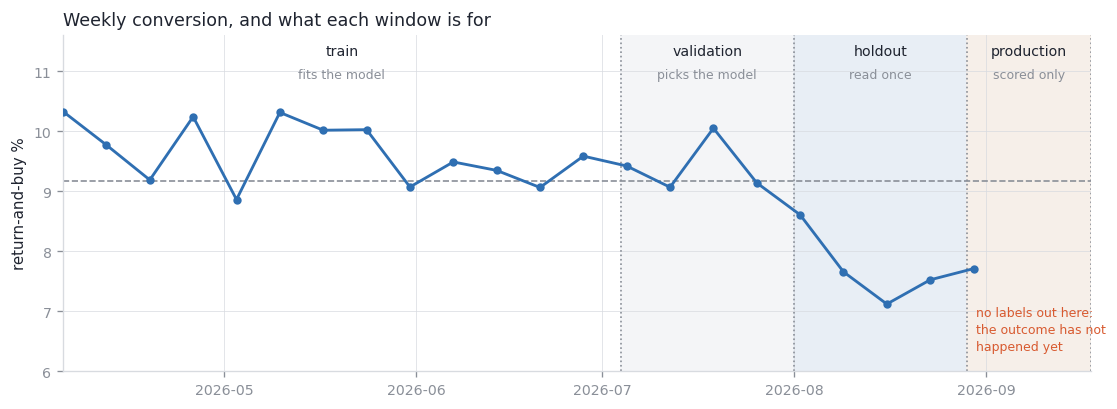

In [2]:
wk = (df.set_index("created_at")
        .resample("W")[Y].agg(n="count", rate="mean")
        .query("n >= 300"))
cut_test = df["created_at"].max() - pd.Timedelta(days=HOLDOUT_DAYS)
cut_valid = cut_test - pd.Timedelta(days=CFG["train"]["validation_days"])
end = df["created_at"].max()
future = end + pd.Timedelta(days=20)          # where production lives

fig, ax = plt.subplots(figsize=(9.4, 3.5))
bands = [(wk.index.min(), cut_valid, "#ffffff", "train", "fits the model"),
         (cut_valid, cut_test, SURFACE, "validation", "picks the model"),
         (cut_test, end, "#e8eef5", "holdout", "read once"),
         (end, future, "#f6efe9", "production", "scored only")]
for lo, hi, colour, label, sub in bands:
    mid = lo + (hi - lo) / 2
    ax.axvspan(lo, hi, color=colour, zorder=0)
    ax.axvline(hi, color=MUTED, lw=1, ls=":", zorder=1)
    ax.annotate(label, (mid, 11.45), ha="center", va="top", fontsize=8.5,
                color=INK, weight="medium")
    ax.annotate(sub, (mid, 11.05), ha="center", va="top", fontsize=7.5, color=MUTED)

ax.plot(wk.index, wk["rate"] * 100, "o-", color=BLUE, lw=1.7, ms=4, zorder=3)
ax.axhline(BASE * 100, ls="--", lw=1, color=MUTED)
ax.annotate("no labels out here:\nthe outcome has not\nhappened yet", (end, 6.3),
            xytext=(5, 0), textcoords="offset points", fontsize=7.5, color=CORAL,
            va="bottom", linespacing=1.4)
ax.set_xlim(wk.index.min(), future)
ax.set_ylim(6, 11.6)
ax.set_title("Weekly conversion, and what each window is for")
ax.set_ylabel("return-and-buy %"); ax.set_xlabel("")
save(fig, "03_weekly_trend")

early = df[df["created_at"] < cut_test][Y].mean()
late = df[df["created_at"] >= cut_test][Y].mean()
print(f"before the cutoff   {early:.2%}")
print(f"holdout period      {late:.2%}    ({late / early - 1:+.0%})")

Roughly 9.5% April–July, then **7.4%** and no recovery. Seasonality, pricing or channel
mix is not knowable from this file — the consequence is: the model trains on one
conversion regime and scores another.

**So the split is by time, never at random.** A random split puts August rows on both
sides, which asks how well the model scores a month it has already read. The three windows
above are three different jobs, and the next section says which is which.

## 2. Three jobs, three windows

Three jobs, easy to conflate, and conflating the first two is the classic leak:

- **Choose the algorithm → the validation window** (the 28 days before the holdout). Both
  algorithms and both baselines are fitted on train and scored here.
- **Quote an honest number → the holdout**, read exactly once, after the choice is fixed.
  Selecting on the window you then quote means the winner is picked partly for fitting
  that window's noise — small with four candidates, but it is the *structure* that leaks,
  and it stops being small the moment anything is tuned.
- **Calibration is neither.** Levels drift with the base rate, so it is re-measured every
  run rather than fixed from one holdout.

Once the algorithm is fixed, the validation window is worth more as training data than as
a referee, so the final model is refitted on train + validation (§4) before the holdout is
scored.

In [3]:
cut_valid = cut_test - pd.Timedelta(days=VALID_DAYS)   # cut_test came from section 1

train = df[df["created_at"] < cut_valid]
valid = df[(df["created_at"] >= cut_valid) & (df["created_at"] < cut_test)]
test = df[df["created_at"] >= cut_test]

# Population statistics (price percentile, the medians that fill a gap) are fitted
# on the training window and reused for every later frame — the same rule the
# serving path follows, so a holdout score is comparable to a served one.
ref = features.fit_reference(train)
X_train, y_train = features.build(train, ref), train[Y].to_numpy(int)
X_valid, y_valid = features.build(valid, ref), valid[Y].to_numpy(int)
y_test = test[Y].to_numpy(int)
margin_valid = valid["expected_margin"].to_numpy(float)
margin_test = test["expected_margin"].to_numpy(float)

for name, part, y in [("train", train, y_train), ("validation", valid, y_valid),
                      ("holdout", test, y_test)]:
    print(f"{name:<11} {len(part):>6,} rows   "
          f"{part['created_at'].min():%b %d} → {part['created_at'].max():%b %d}   "
          f"base rate {y.mean():.2%}")

print(f"\nthe newest {HOLDOUT_DAYS} days also absorb the 7-day attribution window")
print("assumed in the README's data-assumptions section, so no row with a possibly-unfinished")
print("label reaches the training set.")

train       31,204 rows   Apr 01 → Jul 03   base rate 9.63%
validation   9,416 rows   Jul 04 → Jul 31   base rate 9.42%
holdout      9,380 rows   Aug 01 → Aug 28   base rate 7.38%

the newest 28 days also absorb the 7-day attribution window
assumed in the README's data-assumptions section, so no row with a possibly-unfinished
label reaches the training set.


## 3. Six candidates, one validation window

Four models and two baselines, all fitted on train and scored on the same validation rows.
The holdout is not touched here.

The models are one per family, so the comparison says something about the *kind* of model
rather than about one library's defaults: a linear baseline, boosted trees, and two
bagged-tree variants that differ only in how they choose splits. The rule-based baseline
is the one that matters most — it is what the floor could do with a whiteboard.

The production job fits **only the winner** (`train.candidates` in the config). This
notebook is where the field is re-opened: run it when the data changes, and move the
config if the answer moves.

In [4]:
CANDIDATES = list(features.MODELS)      # every model the codebase defines

results, fitted = {}, {}
for algo in CANDIDATES:
    pipe = features.make_pipeline(algo, CFG["train"]["random_state"]).fit(X_train, y_train)
    fitted[algo] = pipe
    results[algo] = metrics.evaluate(y_valid, pipe.predict_proba(X_valid)[:, 1], margin_valid)

results["rule of thumb"] = metrics.evaluate(
    y_valid, features.rule_baseline(valid), margin_valid)
results["random order"] = metrics.evaluate(
    y_valid, np.random.default_rng(42).random(len(y_valid)), margin_valid)

table = pd.DataFrame({k: {"PR-AUC": v["pr_auc"], "ROC-AUC": v["roc_auc"],
                          "Brier": v["brier"]} for k, v in results.items()}).T
best = table.loc[CANDIDATES, "PR-AUC"].idxmax()
print(table.round(4))
print(f"\nselected on validation: {best}")

               PR-AUC  ROC-AUC   Brier
logreg         0.2054   0.7098  0.2182
gbdt           0.1855   0.6900  0.2000
rf             0.1904   0.7040  0.1877
extratrees     0.1862   0.6941  0.2109
rule of thumb  0.1485   0.6667  0.8041
random order   0.0946   0.5038  0.3304

selected on validation: logreg


selected: logreg   PR-AUC 0.2054  vs rule of thumb 0.1485
the three tree models land between 0.1855 and 0.1904


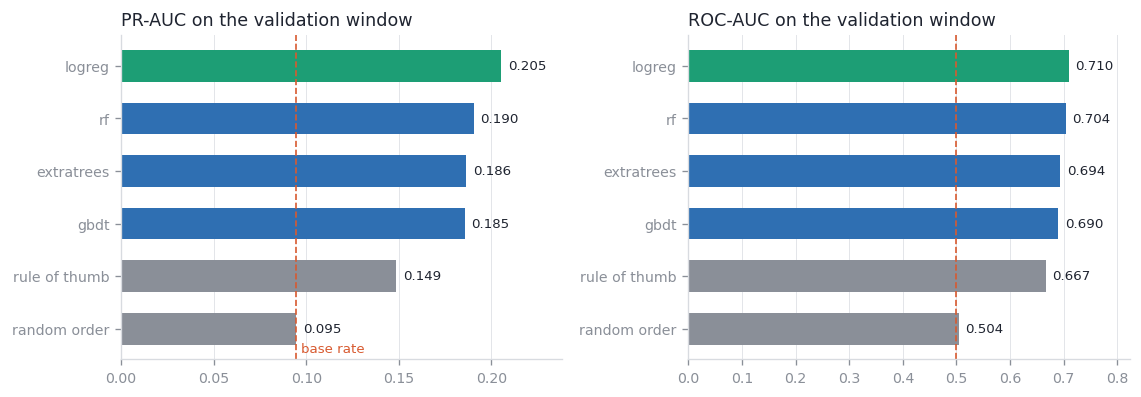

In [5]:
order = table.sort_values("PR-AUC")
colors = [TEAL if i == best else BLUE if i in CANDIDATES else MUTED for i in order.index]

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
for ax, col, ref, ref_label in [(axes[0], "PR-AUC", y_valid.mean(), "base rate"),
                                (axes[1], "ROC-AUC", 0.5, "")]:
    ax.barh(range(len(order)), order[col], color=colors, height=0.6)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order.index)
    ax.axvline(ref, ls="--", lw=1, color=CORAL)
    if ref_label:
        ax.annotate(ref_label, (ref, -0.45), xytext=(3, 0), textcoords="offset points",
                    fontsize=8, color=CORAL)
    for i, v in enumerate(order[col]):
        ax.annotate(f"{v:.3f}", (v, i), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8)
    ax.set_title(f"{col} on the validation window"); ax.margins(x=0.16)
    ax.grid(axis="y", visible=False)
save(fig, "03_candidates")

spread = table.loc[CANDIDATES, "PR-AUC"]
print(f"selected: {best}   PR-AUC {spread[best]:.4f}  "
      f"vs rule of thumb {results['rule of thumb']['pr_auc']:.4f}")
print(f"the three tree models land between {spread.drop(best).min():.4f} and "
      f"{spread.drop(best).max():.4f}" if best == "logreg" else "")

**The linear model wins, and not narrowly** — about 8% more PR-AUC than the best tree
model. That is worth pausing on, because "gradient boosting wins on tabular data" is the
default expectation.

It follows from notebook 01: the strongest pairwise association in the whole dataset is
0.25 and the strongest separation from the target is 0.22. There are no deep interactions
to discover, so the extra capacity of a tree ensemble buys variance rather than signal —
and the two engineered interactions the trees might have found (`is_expired`,
`expiry_x_abandonment`) are already handed to every candidate. It is not a tuning
artefact: a 20-point sweep over leaf size and feature sampling put the whole bagged-tree
family between 0.18 and 0.19.

The hand-written rule is a respectable baseline too — four binary conditions, far better
than chance. Beating *that* is the honest measure of what the modelling bought. ROC-AUC
~0.70 is the ceiling here, and no feature shows an implausible lift, which is the good
news: nothing to leak.

**The algorithm is now fixed.** Nothing below can change it.

## 4. Refit, then calibrate

The choice is made, so the validation window goes back to being training data — it is the
most recent period available. The winner is refitted from scratch on `train + validation`,
exactly as `train.py` does.

Then calibration. `class_weight="balanced"` is right for ranking but inflates raw
probabilities ~3×. Harmless for order (PR-AUC and ROC-AUC are rank-based), serious for the
queue, which multiplies probability by margin.

holdout   pr_auc 0.1540   roc_auc 0.7010   brier 0.0667  (uncalibrated brier 0.2209)
validation pr_auc for logreg was 0.2054 — the gap between the two is drift plus noise, not a mistake
mean score before   44.19%   Brier 0.2209
mean score after    9.58%   Brier 0.0667
observed            7.38%
PR-AUC              0.1579 → 0.1540  (rank-based, so ~unchanged)


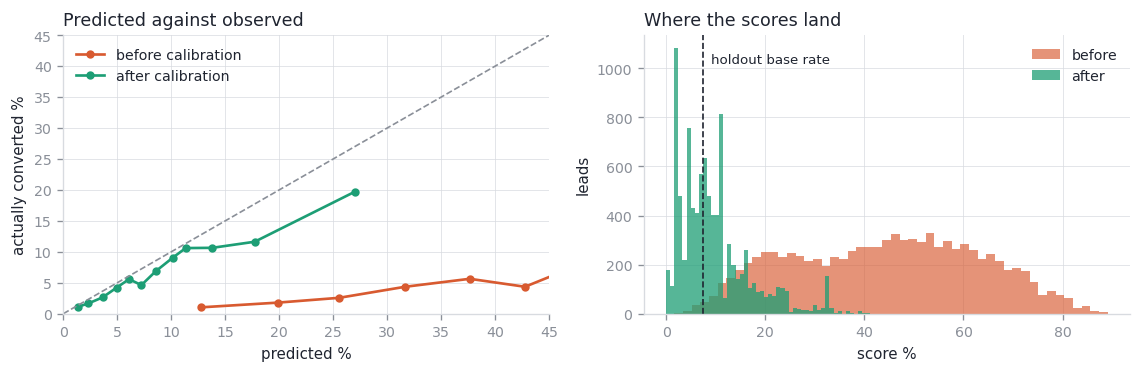

In [6]:
fit_rows = df[df["created_at"] < cut_test]
ref = features.fit_reference(fit_rows)          # widened with the validation window
X_fit = features.build(fit_rows, ref)
X_test = features.build(test, ref)
y_fit = fit_rows["completed_purchase"].to_numpy(int)

raw = features.make_pipeline(best, CFG["train"]["random_state"]).fit(X_fit, y_fit)
raw_prob = raw.predict_proba(X_test)[:, 1]

# cv=3 refits the base pipeline internally, so it is handed over unfitted.
cal = CalibratedClassifierCV(
    features.make_pipeline(best, CFG["train"]["random_state"]), method="isotonic", cv=3)
cal.fit(X_fit, y_fit)
cal_prob = cal.predict_proba(X_test)[:, 1]

# First and only look at the holdout.
cal_res = metrics.evaluate(y_test, cal_prob, margin_test)
raw_res = metrics.evaluate(y_test, raw_prob, margin_test)
print(f"holdout   pr_auc {cal_res['pr_auc']:.4f}   roc_auc {cal_res['roc_auc']:.4f}   "
      f"brier {cal_res['brier']:.4f}  (uncalibrated brier {raw_res['brier']:.4f})")
print(f"validation pr_auc for {best} was {results[best]['pr_auc']:.4f} — the gap between "
      "the two is drift plus noise, not a mistake")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.2))
for name, prob, c in [("before", raw_prob, CORAL), ("after", cal_prob, TEAL)]:
    pts = metrics.calibration_curve(y_test, prob)
    axes[0].plot([p["predicted"] * 100 for p in pts], [p["observed"] * 100 for p in pts],
                 "o-", color=c, lw=1.6, ms=4, label=f"{name} calibration")
lim = 45
axes[0].plot([0, lim], [0, lim], ls="--", lw=1, color=MUTED)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_title("Predicted against observed")
axes[0].set_xlabel("predicted %"); axes[0].set_ylabel("actually converted %")
axes[0].legend()

axes[1].hist(raw_prob * 100, bins=50, color=CORAL, alpha=0.65, label="before")
axes[1].hist(cal_prob * 100, bins=50, color=TEAL, alpha=0.75, label="after")
axes[1].axvline(y_test.mean() * 100, ls="--", lw=1, color=INK)
axes[1].annotate("holdout base rate", (y_test.mean() * 100, axes[1].get_ylim()[1] * 0.9),
                 xytext=(5, 0), textcoords="offset points", fontsize=8, color=INK)
axes[1].set_title("Where the scores land")
axes[1].set_xlabel("score %"); axes[1].set_ylabel("leads"); axes[1].legend()
save(fig, "03_calibration")

# both columns are the holdout, so before/after is a like-for-like comparison
print(f"mean score before   {raw_prob.mean():.2%}   Brier {raw_res['brier']:.4f}")
print(f"mean score after    {cal_prob.mean():.2%}   Brier {cal_res['brier']:.4f}")
print(f"observed            {y_test.mean():.2%}")
print(f"PR-AUC              {raw_res['pr_auc']:.4f} → {cal_res['pr_auc']:.4f}  (rank-based, so ~unchanged)")

Isotonic regression fixes the level without touching the order: mean score falls from ~44%
to ~9.6%, Brier improves ~3×, PR-AUC moves in the third decimal. The number on screen can
now be read as a probability.

**One caveat, and it is §1 again:** the calibrator is fitted on train + validation, so the
mean lands on that period's base rate (~9.6%) while the holdout converted at 7.4%. July
converted at 9.4%, so widening the fit does not rescue it — the fitting data is one regime
throughout. This is why the score distribution is recorded on every run: recalibration is
expected, not exceptional.

Holdout PR-AUC also sits a little below the validation PR-AUC that chose the model. That
gap is what the old two-way split was hiding.

## 5. The number the floor cares about

Work down the ranked queue and watch how fast the buyers accumulate.

   k  precision %  recall %  lift  margin captured %
 250        22.00       7.9  2.98                7.3
 500        21.00      15.2  2.85               13.2
1000        18.30      26.4  2.48               24.1
2500        13.64      49.3  1.85               44.5


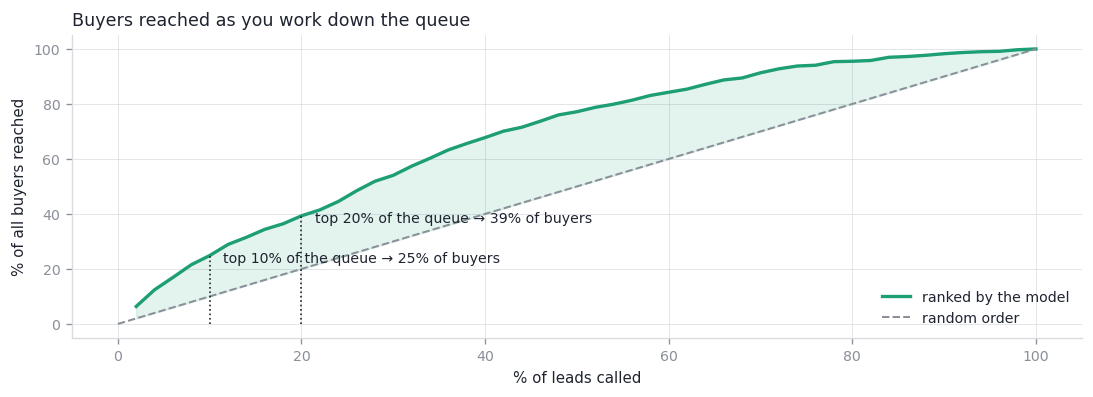

In [7]:
gains = cal_res["gains"]
depth = [g["depth"] * 100 for g in gains]
captured = [g["captured"] * 100 for g in gains]

fig, ax = plt.subplots(figsize=(9.2, 3.4))
ax.plot(depth, captured, color=TEAL, lw=2, label="ranked by the model")
ax.plot([0, 100], [0, 100], ls="--", lw=1.2, color=MUTED, label="random order")
ax.fill_between(depth, captured, depth, color=TEAL, alpha=0.12)
for d in (10, 20):
    c = captured[min(int(d / 2) - 1, len(captured) - 1)]
    ax.plot([d, d], [0, c], lw=1, ls=":", color=INK)
    ax.annotate(f"top {d}% of the queue → {c:.0f}% of buyers", (d, c),
                xytext=(8, -4), textcoords="offset points", fontsize=8.5, color=INK)
ax.set_title("Buyers reached as you work down the queue")
ax.set_xlabel("% of leads called"); ax.set_ylabel("% of all buyers reached")
ax.legend(loc="lower right")
save(fig, "03_gains")

atk = pd.DataFrame(cal_res["at_k"])
atk["precision %"] = (atk["precision"] * 100).round(2)
atk["recall %"] = (atk["recall"] * 100).round(1)
atk["lift"] = atk["lift"].round(2)
atk["margin captured %"] = (atk["margin_capture"] * 100).round(1)
print(atk[["k", "precision %", "recall %", "lift", "margin captured %"]].to_string(index=False))

Read it as a capacity plan: at 500 calls the list converts at ~3× the base rate. That is
the business case, stated without reference to any AUC.

- **Lift falls as k grows** — healthy. The model front-loads the buyers, so digging deeper
  approaches the average. A flat lift curve would mean the ranking carries nothing.
- **Margin capture runs ahead of recall**, because the queue ranks expected value, not
  probability: it prefers a slightly less likely buyer on a policy worth 1.5× more.

## 6. Persisting the model

Notebooks 04 and 05 need this exact fitted pipeline, so it goes to `../artifacts/` with the
population reference row explanations are measured against.

In [8]:
from priority_engine import interpret

bundle = {"pipeline": cal, "reference": interpret.reference_row(X_fit),
          # the population price percentiles and medians build() must reuse:
          # without them a single-row explanation in notebook 05 would rank that
          # lead against itself and always read 1.0
          "feature_ref": ref,
          "algorithm": best, "version": "notebook",
          "holdout": {"X": X_test, "y": y_test, "margin": margin_test},
          "test_rows": test[["lead_id", "minutes_since_abandonment",
                             "days_to_policy_expiry", "expected_margin"]]}
path = ARTIFACTS / "notebook_model.joblib"
joblib.dump(bundle, path)
print(f"wrote {path.relative_to(ROOT)}  ({path.stat().st_size / 1e6:.1f} MB)")

wrote artifacts/notebook_model.joblib  (2.2 MB)


| Question | Answer |
|---|---|
| Which algorithm? | whichever wins PR-AUC **on the validation window** — the notebook prints it |
| Better than a whiteboard rule? | yes, and the margin over the rule is the honest gain |
| Where does the quoted number come from? | the holdout, scored once, after the algorithm was already fixed |
| Can the score be read as a probability? | yes, after isotonic calibration |
| What does the floor get? | roughly 3× the base rate in the first 500 calls |